In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
# ─── Install dependencies & clone IML-ViT ───────────────────────────────────
!pip install timm -q
!git clone https://github.com/SunnyHaze/IML-ViT.git /kaggle/working/IML-ViT

import sys
sys.path.insert(0, '/kaggle/working/IML-ViT')

print("✓ IML-ViT cloned and added to path")

Cloning into '/kaggle/working/IML-ViT'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 133 (delta 41), reused 27 (delta 23), pack-reused 73 (from 1)
Receiving objects: 100% (133/133), 3.88 MiB | 19.36 MiB/s, done.
Resolving deltas: 100% (58/58), done.
✓ IML-ViT cloned and added to path


In [8]:
!kaggle datasets download -d araftahsanpavel/tgif-subset -p /kaggle/working/

import zipfile
print("Extracting...")
with zipfile.ZipFile('/kaggle/working/tgif-subset.zip', 'r') as z:
    z.extractall('/kaggle/working/')
print("✓ Done")

Dataset URL: https://www.kaggle.com/datasets/araftahsanpavel/tgif-subset
License(s): unknown
100%|███████████████████████████████████████| 8.88G/8.88G [01:09<00:00, 138MB/s]

Extracting...
✓ Done


In [9]:
import os, sys, time, random, json, re, gc
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Kaggle speed flags ─────────────────────────────────────────
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

# ── Hyperparameters ────────────────────────────────────────────
SEED        = 42
IMG_SIZE    = 384
BATCH_SIZE  = 4          # safer for T4
NUM_EPOCHS  = 12         # 20 is too long for Kaggle free
LR          = 1e-4
NUM_WORKERS = 2
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT   = '/kaggle/working/subset'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif'}

print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | EPOCHS={NUM_EPOCHS}")

Device : cuda
GPU    : Tesla T4
IMG_SIZE=384 | BATCH=4 | EPOCHS=12


In [10]:
class TGIFSubsetDataset(Dataset):
    """
    TGIF subset with category subfolders.

    Naming convention:
        Fake:  {id}_mask_{type}.png_ps_mask.png_sd2_{N}.png
        Mask:  {id}_mask_{type}.png_ps_mask.png
        Orig:  {id}_orig.png

    Matching: mask filename is a literal prefix of fake filename.
    """
    def __init__(self, root, split='training', transform=None, include_authentic=True):
        self.transform = transform
        self.samples   = []

        split_dir  = os.path.join(root, split)
        fakes_dir  = os.path.join(split_dir, 'fakes')
        masks_dir  = os.path.join(split_dir, 'masks')
        images_dir = os.path.join(split_dir, 'images')

        categories = []
        if os.path.isdir(fakes_dir):
            categories = [d for d in os.listdir(fakes_dir)
                          if os.path.isdir(os.path.join(fakes_dir, d))]

        for cat in sorted(categories):
            cat_fakes  = os.path.join(fakes_dir,  cat)
            cat_masks  = os.path.join(masks_dir,  cat)
            cat_images = os.path.join(images_dir, cat)

            mask_files = {}
            if os.path.isdir(cat_masks):
                for f in os.listdir(cat_masks):
                    if os.path.splitext(f)[1].lower() in IMG_EXTS:
                        mask_files[f] = os.path.join(cat_masks, f)

            if os.path.isdir(cat_fakes):
                for fake_name in sorted(os.listdir(cat_fakes)):
                    if os.path.splitext(fake_name)[1].lower() not in IMG_EXTS:
                        continue
                    matched_mask = None
                    for mask_name, mask_path in mask_files.items():
                        if fake_name.startswith(mask_name):
                            matched_mask = mask_path
                            break
                    if matched_mask:
                        self.samples.append((
                            os.path.join(cat_fakes, fake_name),
                            matched_mask,
                            1))   # forged

            if include_authentic and os.path.isdir(cat_images):
                for f in sorted(os.listdir(cat_images)):
                    if os.path.splitext(f)[1].lower() in IMG_EXTS:
                        self.samples.append((
                            os.path.join(cat_images, f),
                            None,
                            0))   # authentic

        n_forged = sum(1 for s in self.samples if s[2] == 1)
        n_auth   = sum(1 for s in self.samples if s[2] == 0)
        print(f"  {split}: {len(self.samples)} total  "
              f"({n_forged} forged, {n_auth} authentic)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]

        image = np.array(Image.open(img_path).convert('RGB'))

        if mask_path is not None:
            mask_img = Image.open(mask_path).convert('L')
            if mask_img.size != (image.shape[1], image.shape[0]):
                mask_img = mask_img.resize(
                    (image.shape[1], image.shape[0]),
                    resample=Image.NEAREST)
            mask = (np.array(mask_img) > 127).astype(np.float32)
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask)
        mask  = mask.unsqueeze(0).float()
        label = torch.tensor(float(label))

        return image, mask, label


# ── Transforms (no heavy augmentation for fair comparison) ────────────────────
train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

print("Building datasets...")
train_ds = TGIFSubsetDataset(DATA_ROOT, 'training',   transform=train_tf)
val_ds   = TGIFSubsetDataset(DATA_ROOT, 'validation', transform=val_tf)
test_ds  = TGIFSubsetDataset(DATA_ROOT, 'testing',    transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

batch = next(iter(train_loader))
print(f"\nBatch — Image: {batch[0].shape}  Mask: {batch[1].shape}  Label: {batch[2].shape}")

Building datasets...
  training: 7559 total  (5459 forged, 2100 authentic)
  validation: 1023 total  (682 forged, 341 authentic)
  testing: 1029 total  (686 forged, 343 authentic)

Batch — Image: torch.Size([4, 3, 384, 384])  Mask: torch.Size([4, 1, 384, 384])  Label: torch.Size([4])


In [37]:
import gc, torch, os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Kill any lingering model references from this session
for var in ['model', '_m', '_x', '_seg', '_edge']:
    if var in dir():
        del var

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

free, total = torch.cuda.mem_get_info()
print(f"GPU free : {free/1024**3:.2f} GB / {total/1024**3:.2f} GB")
print(f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU free : 13.96 GB / 14.56 GB
Allocated: 0.34 GB


In [11]:
import timm
import torch.utils.checkpoint as checkpoint_utils

class IMLViT(nn.Module):
    def __init__(self, img_size=384, pretrained=True, use_grad_ckpt=True):
        super().__init__()
        self.img_size         = img_size
        self.patch_size       = 16
        self.num_patches_side = img_size // self.patch_size
        self.use_grad_ckpt    = use_grad_ckpt
        self.dec_size         = img_size // 4   # 96

        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            img_size=img_size,
            num_classes=0,
            global_pool='',
        )
        embed_dim = self.backbone.embed_dim

        self.tap_indices = [2, 5, 8, 11]

        self.reduce = nn.ModuleList([
            nn.Conv2d(embed_dim, 64, 1) for _ in self.tap_indices
        ])
        self.fpn_lateral = nn.ModuleList([
            nn.Conv2d(64, 64, 3, padding=1) for _ in self.tap_indices
        ])

        self.seg_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, 1),
        )

        self.edge_head = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1),
        )

    def _reshape_tokens(self, tokens):
        B, N, C = tokens.shape
        H = W = self.num_patches_side
        return tokens.permute(0,2,1).reshape(B,C,H,W)

    def _run_block(self, block, x):
        return block(x)

    def forward(self, x):
        B = x.shape[0]

        tok = self.backbone.patch_embed(x)
        cls_token = self.backbone.cls_token.expand(B,-1,-1)
        tok = torch.cat([cls_token, tok], dim=1)
        tok = self.backbone.pos_drop(tok + self.backbone.pos_embed)

        feats = []
        for i, block in enumerate(self.backbone.blocks):

            if self.use_grad_ckpt and self.training:
                tok = checkpoint_utils.checkpoint(
                    self._run_block, block, tok, use_reentrant=False)
            else:
                tok = block(tok)

            # freeze first 6 blocks for first 5 epochs handled in trainer
            if i in self.tap_indices:
                feats.append(self._reshape_tokens(tok[:,1:,:]))

        feats = [F.relu(lat(r(f))) for r, lat, f in zip(self.reduce, self.fpn_lateral, feats)]

        upsampled = [
            F.interpolate(f, size=(self.dec_size,self.dec_size),
                          mode='bilinear', align_corners=False)
            for f in feats
        ]

        fused = torch.cat(upsampled, dim=1)

        seg_low  = self.seg_head(fused)
        edge_low = self.edge_head(upsampled[-1])

        seg_logits = F.interpolate(seg_low, size=(self.img_size,self.img_size),
                                   mode='bilinear', align_corners=False)
        edge_logits = F.interpolate(edge_low, size=(self.img_size,self.img_size),
                                    mode='bilinear', align_corners=False)

        return seg_logits, edge_logits


def build_iml_vit(img_size=384, pretrained=True):
    return IMLViT(img_size=img_size, pretrained=pretrained, use_grad_ckpt=True)


gc.collect()
torch.cuda.empty_cache()

_m = build_iml_vit(IMG_SIZE).to(DEVICE)
_x = torch.randn(1,3,IMG_SIZE,IMG_SIZE, device=DEVICE)
with torch.no_grad():
    _seg, _edge = _m(_x)

print("Seg :", _seg.shape)
print("Edge:", _edge.shape)
print(f"Peak VRAM: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")

del _m,_x,_seg,_edge
gc.collect()
torch.cuda.empty_cache()
print("✓ Memory-safe IML-ViT ready")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Seg : torch.Size([1, 1, 384, 384])
Edge: torch.Size([1, 1, 384, 384])
Peak VRAM: 4.46 GB
✓ Memory-safe IML-ViT ready


In [12]:
def get_edge_mask(mask, dilation=5):
    """
    Generate binary edge mask from a segmentation mask via max-pool dilation.
    mask: (B, 1, H, W) float tensor
    """
    dilated  = F.max_pool2d(mask,  kernel_size=dilation, stride=1,
                             padding=dilation // 2)
    eroded   = -F.max_pool2d(-mask, kernel_size=dilation, stride=1,
                               padding=dilation // 2)
    edge     = (dilated - eroded).clamp(0, 1)
    return edge


class IMLViTLoss(nn.Module):
    """
    Combined segmentation + edge loss.
      L = 0.5 * DiceBCE(seg) + 0.5 * BCE(edge)
    """
    def __init__(self, smooth=1.0, edge_weight=0.5):
        super().__init__()
        self.bce          = nn.BCEWithLogitsLoss()
        self.smooth       = smooth
        self.edge_weight  = edge_weight

    def _dice_bce(self, logits, targets):
        bce  = self.bce(logits, targets)
        prob = torch.sigmoid(logits).view(logits.size(0), -1)
        tgt  = targets.view(targets.size(0), -1)
        inter = (prob * tgt).sum(dim=1)
        union = prob.sum(dim=1) + tgt.sum(dim=1)
        dice  = 1.0 - ((2 * inter + self.smooth) / (union + self.smooth)).mean()
        return 0.5 * bce + 0.5 * dice

    def forward(self, seg_logits, edge_logits, masks):
        seg_loss  = self._dice_bce(seg_logits, masks)
        edge_gt   = get_edge_mask(masks)
        edge_loss = self.bce(edge_logits, edge_gt)
        return (1 - self.edge_weight) * seg_loss + self.edge_weight * edge_loss


# ── Training loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    start = time.time()

    for images, masks, _labels in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            seg_logits, edge_logits = model(images)
            loss = criterion(seg_logits, edge_logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds   = (torch.sigmoid(seg_logits) > 0.5).float()
        correct += (preds == masks).sum().item()
        total   += masks.numel()

    return total_loss / len(loader.dataset), correct / total, time.time() - start


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, masks, _labels in loader:
        images, masks = images.to(device), masks.to(device)
        with autocast('cuda'):
            seg_logits, edge_logits = model(images)
            loss = criterion(seg_logits, edge_logits, masks)
        total_loss += loss.item() * images.size(0)
        preds   = (torch.sigmoid(seg_logits) > 0.5).float()
        correct += (preds == masks).sum().item()
        total   += masks.numel()

    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def full_evaluation(model, loader, device, threshold=0.5):
    model.eval()
    all_pp, all_pt, all_ip, all_it = [], [], [], []

    for images, masks, labels in loader:
        images = images.to(device)
        with autocast('cuda'):
            seg_logits, _ = model(images)
        probs     = torch.sigmoid(seg_logits).cpu().numpy()
        masks_np  = masks.numpy()
        labels_np = labels.numpy()

        for i in range(probs.shape[0]):
            pred = (probs[i, 0] > threshold).astype(np.int32).flatten()
            gt   = masks_np[i, 0].astype(np.int32).flatten()
            all_pp.append(pred)
            all_pt.append(gt)
            all_ip.append(1 if pred.max() > 0 else 0)
            all_it.append(int(labels_np[i]))

    pp = np.concatenate(all_pp)
    pt = np.concatenate(all_pt)
    ip = np.array(all_ip)
    it = np.array(all_it)

    inter = ((pp == 1) & (pt == 1)).sum()
    union = ((pp == 1) | (pt == 1)).sum()

    return {
        'pixel': {
            'accuracy' : accuracy_score(pt, pp),
            'precision': precision_score(pt, pp, zero_division=0),
            'recall'   : recall_score(pt, pp, zero_division=0),
            'f1'       : f1_score(pt, pp, zero_division=0),
            'iou'      : float(inter / (union + 1e-8)),
            'dice'     : float(2 * inter / (pp.sum() + pt.sum() + 1e-8)),
        },
        'image': {
            'accuracy' : accuracy_score(it, ip),
            'precision': precision_score(it, ip, zero_division=0),
            'recall'   : recall_score(it, ip, zero_division=0),
            'f1'       : f1_score(it, ip, zero_division=0),
        },
        'pixel_cm': confusion_matrix(pt, pp),
        'image_cm': confusion_matrix(it, ip) if len(set(it)) > 1 else np.array([[0]]),
    }

print("✓ Loss / train / eval functions defined")

✓ Loss / train / eval functions defined


In [43]:
import gc
from tqdm.notebook import tqdm
from IPython.display import clear_output

model_name = 'IML_ViT_B16_384_FAST'

print(f"\n{'='*60}")
print(f" TRAINING: {model_name}")
print(f"{'='*60}")

gc.collect()
torch.cuda.empty_cache()

model = build_iml_vit(img_size=IMG_SIZE, pretrained=True).to(DEVICE)

# freeze first half transformer blocks initially
for i, blk in enumerate(model.backbone.blocks):
    if i < 6:
        for p in blk.parameters():
            p.requires_grad = False

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size       = total_params * 4 / 1024**2

print(f"Params: {total_params:,} ({model_size:.1f} MB)")
print(f"Trainable initially: {trainable_params:,}")

criterion = IMLViTLoss(edge_weight=0.5)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = GradScaler('cuda')

history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'epoch_time':[]}
best_val_loss = float('inf')
best_epoch = 0
total_time = 0.0

for epoch in range(1, NUM_EPOCHS+1):

    if epoch == 6:
        print("Unfreezing full ViT backbone...")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR*0.5, weight_decay=1e-4)

    gc.collect()
    torch.cuda.empty_cache()

    model.train()
    total_loss, correct, total = 0.0, 0, 0
    start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS}", leave=False)

    for images, masks, _labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda'):
            seg_logits, edge_logits = model(images)
            loss = criterion(seg_logits, edge_logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(seg_logits) > 0.5).float()
        correct += (preds == masks).sum().item()
        total += masks.numel()

        pbar.set_postfix(loss=f"{total_loss/((total//masks[0].numel())+1):.4f}",
                         acc=f"{correct/total:.4f}")

    tl = total_loss / len(train_loader.dataset)
    ta = correct / total
    et = time.time() - start

    vl, va = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    total_time += et
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    history['epoch_time'].append(et)

    saved = ""
    if vl < best_val_loss:
        best_val_loss = vl
        best_epoch = epoch
        torch.save(model.state_dict(), f'/kaggle/working/best_{model_name}.pth')
        saved = " ✔ best saved"

    clear_output(wait=True)
    print(f"\n{'='*72}")
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"{'='*72}")
    print(f"Train Loss : {tl:.4f}")
    print(f"Train Acc  : {ta:.4f}")
    print(f"Val Loss   : {vl:.4f}")
    print(f"Val Acc    : {va:.4f}")
    print(f"Epoch Time : {et:.1f}s")
    print(f"Best Epoch : {best_epoch} (Val {best_val_loss:.4f})")
    print(f"GPU Used   : {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    print(saved)

history['total_time'] = total_time

print("\nRunning final test evaluation...")
model.load_state_dict(torch.load(f'/kaggle/working/best_{model_name}.pth', map_location=DEVICE))
results = full_evaluation(model, test_loader, DEVICE)

meta = {
    'params': total_params,
    'trainable': trainable_params,
    'size_mb': model_size,
}

print(f"\n{'─'*60}")
print(f"FINAL RESULTS: {model_name}")
print(f"{'─'*60}")
print(f"Pixel F1   : {results['pixel']['f1']:.4f}")
print(f"Pixel IoU  : {results['pixel']['iou']:.4f}")
print(f"Pixel Dice : {results['pixel']['dice']:.4f}")
print(f"Image F1   : {results['image']['f1']:.4f}")
print(f"Image Acc  : {results['image']['accuracy']:.4f}")
print(f"Train Time : {int(total_time//60)}m {int(total_time%60)}s")
print(f"{'─'*60}")


Epoch 12/12
Train Loss : 0.1693
Train Acc  : 0.9761
Val Loss   : 0.2821
Val Acc    : 0.9475
Epoch Time : 360.4s
Best Epoch : 2 (Val 0.2614)
GPU Used   : 1.67 GB


Running final test evaluation...

────────────────────────────────────────────────────────────
FINAL RESULTS: IML_ViT_B16_384_FAST
────────────────────────────────────────────────────────────
Pixel F1   : 0.3506
Pixel IoU  : 0.2126
Pixel Dice : 0.3506
Image F1   : 0.7897
Image Acc  : 0.6579
Train Time : 67m 44s
────────────────────────────────────────────────────────────


In [46]:
import gc, time
from tqdm.notebook import tqdm
from IPython.display import clear_output

# ─────────────────────────────────────────────
# CONFIG: continue training only remaining epochs
# ─────────────────────────────────────────────
START_EPOCH = 13
END_EPOCH   = 20

print(f"\n{'='*60}")
print(f" CONTINUING TRAINING: Epoch {START_EPOCH} → {END_EPOCH}")
print(f"{'='*60}")

gc.collect()
torch.cuda.empty_cache()

# ─────────────────────────────────────────────
# Reload model
# ─────────────────────────────────────────────
model = build_iml_vit(img_size=IMG_SIZE, pretrained=False).to(DEVICE)

model.load_state_dict(
    torch.load('/kaggle/working/best_IML_ViT_B16_384_FAST.pth',
               map_location=DEVICE)
)

print("✓ Model loaded")

# ─────────────────────────────────────────────
# IMPORTANT: re-init optimizer + scheduler
# (we are continuing fine-tuning phase)
# ─────────────────────────────────────────────
criterion = IMLViTLoss(edge_weight=0.5)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR*0.5, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=(END_EPOCH - START_EPOCH + 1),
    eta_min=1e-6
)

scaler = GradScaler('cuda')

# ─────────────────────────────────────────────
# CONTINUE HISTORY (if already exists)
# ─────────────────────────────────────────────
try:
    history
except:
    history = {'train_loss':[], 'val_loss':[],
               'train_acc':[], 'val_acc':[],
               'epoch_time':[]}

total_time = 0.0

# ─────────────────────────────────────────────
# TRAIN LOOP (ONLY 13–20)
# ─────────────────────────────────────────────
for epoch in range(START_EPOCH, END_EPOCH + 1):

    gc.collect()
    torch.cuda.empty_cache()

    model.train()
    total_loss, correct, total = 0.0, 0, 0
    start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{END_EPOCH}", leave=False)

    for images, masks, _ in pbar:
        images = images.to(DEVICE, non_blocking=True)
        masks  = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda'):
            seg_logits, edge_logits = model(images)
            loss = criterion(seg_logits, edge_logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(seg_logits) > 0.5).float()
        correct += (preds == masks).sum().item()
        total += masks.numel()

        pbar.set_postfix(loss=total_loss/(total+1e-6),
                         acc=correct/(total+1e-6))

    tl = total_loss / len(train_loader.dataset)
    ta = correct / total
    et = time.time() - start

    vl, va = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    history['epoch_time'].append(et)

    total_time += et

    # save best
    if 'best_val_loss' not in globals():
        best_val_loss = float('inf')

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(),
                   '/kaggle/working/best_IML_ViT_B16_384_FAST.pth')
        print("✔ Saved best model")

    clear_output(wait=True)

    print(f"\nEpoch {epoch}/{END_EPOCH}")
    print(f"Train Loss: {tl:.4f} | Acc: {ta:.4f}")
    print(f"Val Loss  : {vl:.4f} | Acc: {va:.4f}")
    print(f"Time      : {et:.1f}s")
    print(f"Best VL   : {best_val_loss:.4f}")


Epoch 20/20
Train Loss: 0.1370 | Acc: 0.9870
Val Loss  : 0.2823 | Acc: 0.9540
Time      : 361.5s
Best VL   : 0.2614


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ─────────────────────────────────────────────────────────────
# Helper: show GT vs Prediction
# ─────────────────────────────────────────────────────────────
@torch.no_grad()
def visualize_predictions(model, loader, device, n_samples=4):
    model.eval()
    shown = 0

    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3*n_samples))
    fig.suptitle(f"{model_name} — Ground Truth vs Prediction", fontsize=14, fontweight='bold')

    for images, masks, labels in loader:
        images = images.to(device)

        with autocast('cuda'):
            seg_logits, _ = model(images)

        probs = torch.sigmoid(seg_logits).cpu()

        for i in range(images.size(0)):
            if shown >= n_samples:
                plt.tight_layout()
                plt.show()
                return

            img = images[i].cpu().permute(1,2,0).numpy()
            img = img * np.array(STD) + np.array(MEAN)
            img = np.clip(img,0,1)

            gt   = masks[i,0].numpy()
            pred = (probs[i,0].numpy() > 0.5).astype(np.float32)

            axes[shown,0].imshow(img)
            axes[shown,0].set_title("Input Image")
            axes[shown,0].axis('off')

            axes[shown,1].imshow(gt, cmap='gray')
            axes[shown,1].set_title("Ground Truth Mask")
            axes[shown,1].axis('off')

            axes[shown,2].imshow(pred, cmap='gray')
            axes[shown,2].set_title("Predicted Mask")
            axes[shown,2].axis('off')

            shown += 1

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# GT vs Prediction Samples
# ─────────────────────────────────────────────────────────────
visualize_predictions(model, test_loader, DEVICE, n_samples=5)


# ─────────────────────────────────────────────────────────────
# Curves + Normalized Confusion Matrix
# ─────────────────────────────────────────────────────────────
epochs = range(1, len(history['train_loss'])+1)

fig, axes = plt.subplots(1, 3, figsize=(20,5))
fig.suptitle(f"{model_name} — Training Analysis", fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], linewidth=2, label='Train')
axes[0].plot(epochs, history['val_loss'], linewidth=2, label='Validation')
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], linewidth=2, label='Train')
axes[1].plot(epochs, history['val_acc'], linewidth=2, label='Validation')
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Normalized confusion matrix
cm = results['image_cm'].astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap='Blues',
            xticklabels=['Authentic','Forged'],
            yticklabels=['Authentic','Forged'],
            ax=axes[2])

axes[2].set_title("Normalized Image-level Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.savefig(f'/kaggle/working/{model_name}_analysis.png', dpi=160, bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# Complete Metrics Table
# ─────────────────────────────────────────────────────────────
summary = {
    'Model Name'        : model_name,
    'Pixel Accuracy'    : round(results['pixel']['accuracy'],4),
    'Pixel Precision'   : round(results['pixel']['precision'],4),
    'Pixel Recall'      : round(results['pixel']['recall'],4),
    'Pixel F1 Score'    : round(results['pixel']['f1'],4),
    'Pixel IoU'         : round(results['pixel']['iou'],4),
    'Pixel Dice Score'  : round(results['pixel']['dice'],4),
    'Image Accuracy'    : round(results['image']['accuracy'],4),
    'Image Precision'   : round(results['image']['precision'],4),
    'Image Recall'      : round(results['image']['recall'],4),
    'Image F1 Score'    : round(results['image']['f1'],4),
    'Parameters'        : f"{meta['params']:,}",
    'Trainable Params'  : f"{meta['trainable']:,}",
    'Model Size (MB)'   : round(meta['size_mb'],2),
    'Avg Epoch Time(s)' : round(history['total_time']/len(history['epoch_time']),2),
    'Total Train Time(s)': round(history['total_time'],2)
}

df = pd.DataFrame([summary])
print("\n")
print(df.to_string(index=False))

df.to_csv(f'/kaggle/working/{model_name}_metrics.csv', index=False)
print(f"\n✓ Saved metrics CSV")



          Model Name  Pixel Accuracy  Pixel Precision  Pixel Recall  Pixel F1 Score  Pixel IoU  Pixel Dice Score  Image Accuracy  Image Precision  Image Recall  Image F1 Score Parameters Trainable Params  Model Size (MB)  Avg Epoch Time(s)  Total Train Time(s)
IML_ViT_B16_384_FAST          0.9405           0.3251        0.3804          0.3506     0.2126            0.3506          0.6579            0.669        0.9636          0.7897 86,822,850       44,295,618            331.2             203.25               4065.0

✓ Saved metrics CSV


In [45]:
save_package = {
    model_name: {
        'pixel_metrics' : results['pixel'],
        'image_metrics' : results['image'],
        'pixel_confusion_matrix': results['pixel_cm'].tolist(),
        'image_confusion_matrix': results['image_cm'].tolist(),
        'history' : history,
        'meta'    : meta,
    }
}

with open(f'/kaggle/working/{model_name}_complete_results.json', 'w') as f:
    json.dump(save_package, f, indent=2, default=str)

print("\n" + "="*65)
print(" ALL ARTIFACTS SAVED TO KAGGLE OUTPUT ")
print("="*65)
print(f"✓ /kaggle/working/best_{model_name}.pth")
print(f"✓ /kaggle/working/{model_name}_analysis.png")
print(f"✓ /kaggle/working/{model_name}_metrics.csv")
print(f"✓ /kaggle/working/{model_name}_complete_results.json")
print("="*65)


 ALL ARTIFACTS SAVED TO KAGGLE OUTPUT 
✓ /kaggle/working/best_IML_ViT_B16_384_FAST.pth
✓ /kaggle/working/IML_ViT_B16_384_FAST_analysis.png
✓ /kaggle/working/IML_ViT_B16_384_FAST_metrics.csv
✓ /kaggle/working/IML_ViT_B16_384_FAST_complete_results.json


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.amp import autocast
from sklearn.metrics import confusion_matrix

# ─────────────────────────────────────────────────────────────
# Ground Truth vs Prediction Visualization
# ─────────────────────────────────────────────────────────────
@torch.no_grad()
def visualize_predictions(model, loader, device, n_samples=5):
    model.eval()

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    fig.suptitle(f"{model_name} — Ground Truth vs Prediction", fontsize=14, fontweight='bold')

    shown = 0

    for images, masks, _ in loader:
        images = images.to(device)

        with autocast('cuda'):
            seg_logits, _ = model(images)

        probs = torch.sigmoid(seg_logits).cpu()

        for i in range(images.size(0)):

            if shown >= n_samples:
                plt.tight_layout()
                plt.show()
                return

            # ── Proper denormalization ─────────────────────────────
            img = images[i].cpu().permute(1,2,0).numpy()
            img = (img * np.array(STD)) + np.array(MEAN)
            img = np.clip(img, 0, 1)

            gt   = masks[i,0].cpu().numpy()
            pred = (probs[i,0].numpy() > 0.5).astype(np.float32)

            axes[shown,0].imshow(img)
            axes[shown,0].set_title("Input Image")
            axes[shown,0].axis('off')

            axes[shown,1].imshow(gt, cmap='gray')
            axes[shown,1].set_title("Ground Truth Mask")
            axes[shown,1].axis('off')

            axes[shown,2].imshow(pred, cmap='gray')
            axes[shown,2].set_title("Predicted Mask")
            axes[shown,2].axis('off')

            shown += 1

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# Run GT vs Prediction
# ─────────────────────────────────────────────────────────────
visualize_predictions(model, test_loader, DEVICE, n_samples=5)


# ─────────────────────────────────────────────────────────────
# Training Curves + Normalized Confusion Matrix
# ─────────────────────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f"{model_name} — Training Analysis", fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], linewidth=2, label='Train')
axes[0].plot(epochs, history['val_loss'], linewidth=2, label='Val')
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], linewidth=2, label='Train')
axes[1].plot(epochs, history['val_acc'], linewidth=2, label='Val')
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion Matrix (Image-level)
cm = results['image_cm'].astype(float)
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["Authentic", "Forged"],
    yticklabels=["Authentic", "Forged"],
    ax=axes[2]
)

axes[2].set_title("Normalized Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.savefig(f'/kaggle/working/{model_name}_analysis.png', dpi=160, bbox_inches='tight')
plt.show()

In [49]:
# ─────────────────────────────────────────────────────────────
# FINAL METRICS SUMMARY TABLE (CLEAN VERSION)
# ─────────────────────────────────────────────────────────────

summary = {
    'Model Name'        : model_name,

    # Pixel-level metrics
    'Pixel Accuracy'    : round(results['pixel']['accuracy'], 4),
    'Pixel Precision'   : round(results['pixel']['precision'], 4),
    'Pixel Recall'      : round(results['pixel']['recall'], 4),
    'Pixel F1 Score'    : round(results['pixel']['f1'], 4),
    'Pixel IoU'         : round(results['pixel']['iou'], 4),
    'Pixel Dice Score'  : round(results['pixel']['dice'], 4),

    # Image-level metrics
    'Image Accuracy'    : round(results['image']['accuracy'], 4),
    'Image Precision'   : round(results['image']['precision'], 4),
    'Image Recall'      : round(results['image']['recall'], 4),
    'Image F1 Score'    : round(results['image']['f1'], 4),

    # Model stats
    'Parameters'        : f"{meta['params']:,}",
    'Trainable Params'  : f"{meta['trainable']:,}",
    'Model Size (MB)'   : round(meta['size_mb'], 2),

    # Training time
    'Avg Epoch Time (s)': round(history['total_time'] / len(history['epoch_time']), 2),
    'Total Train Time (s)': round(history['total_time'], 2)
}

df = pd.DataFrame([summary]).T
df.columns = ["Value"]

print("\n" + "="*60)
print("            IML-ViT FINAL RESULTS SUMMARY")
print("="*60)

display(df)

# Save CSV
df.to_csv(f'/kaggle/working/{model_name}_metrics.csv')

print("\n✓ Saved metrics CSV")


            IML-ViT FINAL RESULTS SUMMARY


,Value
Model Name,IML_ViT_B16_384_FAST
Pixel Accuracy,0.9405
Pixel Precision,0.3251
Pixel Recall,0.3804
Pixel F1 Score,0.3506
Pixel IoU,0.2126
Pixel Dice Score,0.3506
Image Accuracy,0.6579
Image Precision,0.669
Image Recall,0.9636



✓ Saved metrics CSV


In [73]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151553..2.6225708].


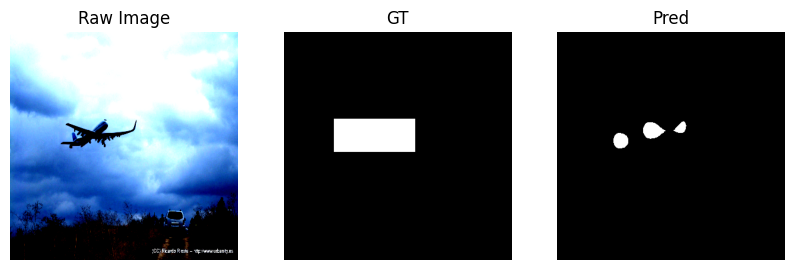

In [74]:
import matplotlib.pyplot as plt
from torch.amp import autocast

images, masks, _ = next(iter(test_loader))

images = images.to(DEVICE)

model.eval()

with torch.no_grad():
    with autocast('cuda'):
        seg_logits, _ = model(images)

pred = torch.sigmoid(seg_logits)[0].detach().cpu().squeeze().numpy()
gt = masks[0].squeeze().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(images[0].cpu().permute(1,2,0))
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt, cmap="gray")
plt.title("GT")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Pred")
plt.axis("off")

plt.show()

In [75]:
print("History keys:", history.keys())
print("Train loss length:", len(history['train_loss']))
print("Val loss length:", len(history['val_loss']))
print("Results keys:", results.keys())

History keys: dict_keys(['train_loss', 'val_loss', 'train_acc', 'val_acc', 'epoch_time', 'total_time'])
Train loss length: 20
Val loss length: 20
Results keys: dict_keys(['pixel', 'image', 'pixel_cm', 'image_cm'])


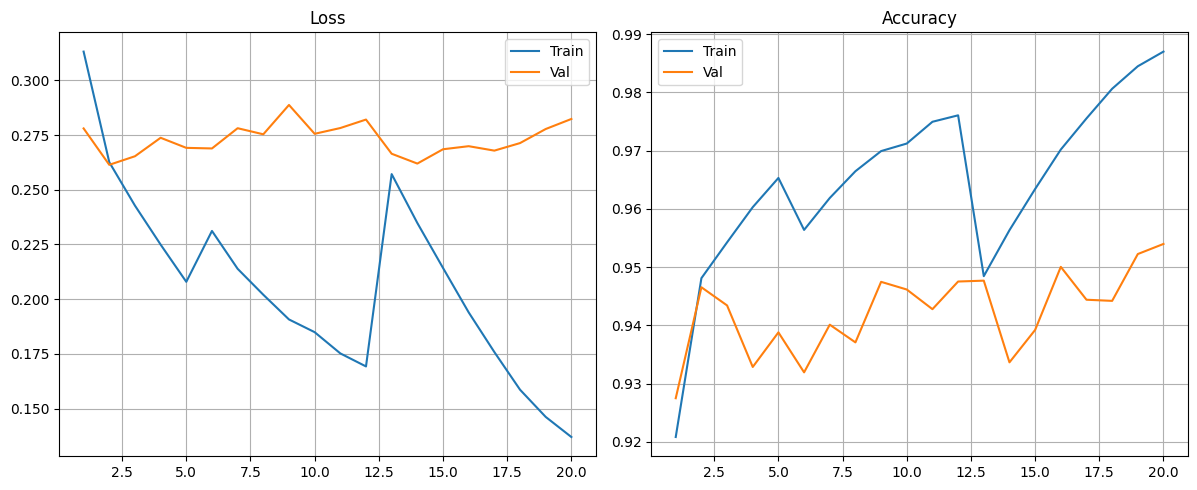

In [76]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(history['train_loss']) + 1)

fig = plt.figure(figsize=(18,5))

# ── LOSS ─────────────────────────────
ax1 = plt.subplot(1,3,1)
ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'], label='Val')
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True)

# ── ACC ──────────────────────────────
ax2 = plt.subplot(1,3,2)
ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'], label='Val')
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True)

# ── FORCE SHOW ───────────────────────
plt.tight_layout()
plt.show()

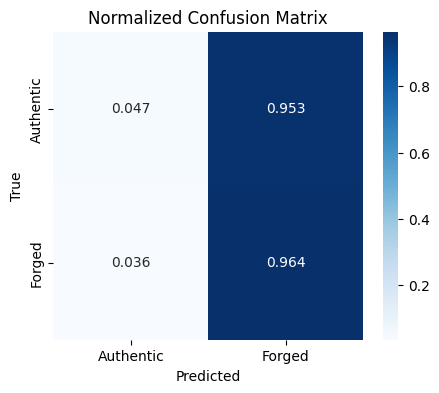

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = results['image_cm'].astype(float)
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["Authentic", "Forged"],
    yticklabels=["Authentic", "Forged"]
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()